## Import 

In [93]:
import pandas as pd

from sklearn.cluster import KMeans
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import confusion_matrix,classification_report

import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

## Data Collection

In [63]:
iris_data = load_iris()
iris_data_df = pd.DataFrame(data = iris_data.data,columns=iris_data.feature_names)
iris_data_x = iris_data_df

In [64]:
iris_output_df = pd.DataFrame(iris_data.target)
iris_output_df.value_counts()

0
0    50
1    50
2    50
Name: count, dtype: int64

## Data Preprocessing

In [71]:
std_scalr = StandardScaler()
scaled_X = std_scalr.fit_transform(iris_data_df)


## Model building with scaled X

In [76]:
kmeans_algo_scaled = KMeans(n_clusters=3,random_state=31)
kmeans_algo_scaled.fit(scaled_X)

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,31
,copy_x,True
,algorithm,'lloyd'


In [77]:
(pd.DataFrame(kmeans_algo_scaled.labels_)).value_counts()

0
1    96
2    33
0    21
Name: count, dtype: int64

## Model building with unscaled X

In [78]:
kmeans_algo = KMeans(n_clusters=3,random_state=22)
kmeans_algo.fit(iris_data_x)

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,22
,copy_x,True
,algorithm,'lloyd'


In [79]:
(pd.DataFrame(kmeans_algo.labels_)).value_counts()

0
2    61
0    50
1    39
Name: count, dtype: int64

In [80]:
kmeans_algo.labels_

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 1, 1, 1, 1, 2, 1, 1, 1,
       1, 1, 1, 2, 2, 1, 1, 1, 1, 2, 1, 2, 1, 2, 1, 1, 2, 2, 1, 1, 1, 1,
       1, 2, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1, 1, 1, 2, 1, 1, 2], dtype=int32)

## Understanding the Cluster segregation

In [81]:
iris_data_df["target"] = kmeans_algo.labels_

In [82]:
iris_data_df.groupby(by="target").agg(["mean"])

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
,mean,mean,mean,mean
target,,,,
0,5.006000,3.428000,1.462000,0.246000
1,6.853846,3.076923,5.715385,2.053846
2,5.883607,2.740984,4.388525,1.434426


In [83]:
iris_data_df.groupby(by="target").agg(["min","max",])

sepal length (cm)      sepal width (cm)      petal length (cm)      petal width (cm)     
                     min  max              min  max               min  max              min  max
target                                                                                          
0                    4.3  5.8              2.3  4.4               1.0  1.9              0.1  0.6
1                    6.1  7.9              2.5  3.8               4.7  6.9              1.4  2.5
2                    4.9  6.8              2.0  3.4               3.0  5.1              1.0  2.4

In [84]:
kmeans_algo.cluster_centers_

array([[5.006     , 3.428     , 1.462     , 0.246     ],
       [6.85384615, 3.07692308, 5.71538462, 2.05384615],
       [5.88360656, 2.74098361, 4.38852459, 1.43442623]])

## Finding the optimal clusters required to obtain the data using the wscc within the cluster sum of squares

In [85]:
wcss = []
for i in range(1,11):
    kmeans_algo = KMeans(n_clusters=i,random_state=32)
    kmeans_algo.fit(iris_data_x)
    wcss.append(kmeans_algo.inertia_)
print(wcss)

[791.5639333333331, 178.73700000000002, 78.8556658259773, 59.992852910602906, 52.900925994381865, 40.24874650720239, 37.756084578031846, 33.61792126576031, 32.12874248120301, 29.850167919799503]


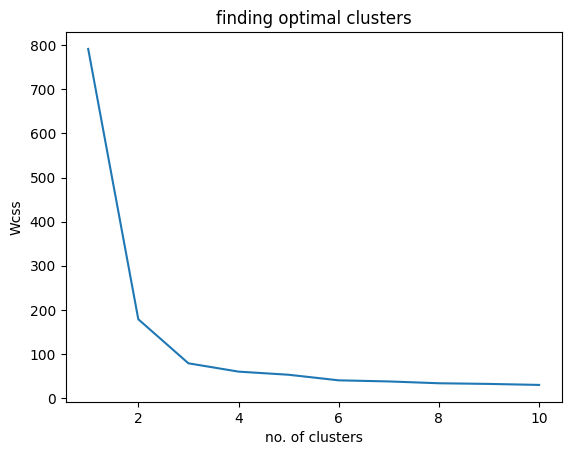

In [86]:
plt.plot(range(1,11),wcss)
plt.xlabel("no. of clusters")
plt.ylabel("Wcss")
plt.title("finding optimal clusters")
plt.show()

## Now take it for supervised Learning

In [89]:
X =iris_data_df.drop("target",axis=1)
y = iris_data_df["target"]

In [90]:
X_train, X_test, y_train, y_test =  train_test_split(X,y,test_size=0.2,random_state=32,shuffle=True,stratify=y)

In [104]:
gradboost_model  = GradientBoostingClassifier(max_depth=3)
gradboost_model.fit(X_train,y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [105]:
pred_y_train = gradboost_model.predict(X_train)
pred_y_test = gradboost_model.predict(X_test)

In [106]:
print(classification_report(y_train,pred_y_train))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        40
           1       1.00      1.00      1.00        31
           2       1.00      1.00      1.00        49

    accuracy                           1.00       120
   macro avg       1.00      1.00      1.00       120
weighted avg       1.00      1.00      1.00       120



In [107]:
print(confusion_matrix(y_train,pred_y_train))

[[40  0  0]
 [ 0 31  0]
 [ 0  0 49]]


In [108]:
print(classification_report(y_test,pred_y_test))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         8
           2       1.00      1.00      1.00        12

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [109]:
print(confusion_matrix(y_test,pred_y_test))

[[10  0  0]
 [ 0  8  0]
 [ 0  0 12]]
